# Laplace vs MCMC Predictive Distribution Test

Verify that the Laplace approximation's predictive distribution matches the true Bayesian posterior sampled via Metropolis-Hastings MCMC.

**Reference:** TODO.md Section 1b, item 2: "Predictive distribution matches Metropolis-Hastings/HMC on a small synthetic problem."

## Strategy

1. Generate a small synthetic dataset (N~50, D~3, K=3)
2. Fit the last-layer Laplace approximation
3. Sample the true posterior using Metropolis-Hastings with the exact log-posterior
4. Compare predictive distributions on test points:
   - Mean predictions (class probabilities)
   - Uncertainty estimates (total entropy, epistemic, aleatoric)
   - Visualize sampled weight distributions vs Laplace Gaussian

The Laplace approximation should be close to MCMC if:
- The posterior is approximately Gaussian near the MAP
- The dataset is not too small (sufficient for asymptotic approximation)
- The prior is reasonable (not too strong)

## Setup

In [21]:
import sys
from pathlib import Path

# Add parent directory to path
root_dir = Path().resolve().parent
sys.path.insert(0, str(root_dir))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from src.bayesian import FeatureClassifier, LastLayerLaplace, entropy

torch.manual_seed(42)
np.random.seed(42)

print("✓ Imports successful")

✓ Imports successful


## Generate Small Synthetic Dataset

In [22]:
# Small problem for tractable MCMC
N_train = 60
N_test = 20
D = 3   # feature dimension (without bias)
K = 3   # 3-class classification

def make_data(centers, N, D, K, seed):
    torch.manual_seed(seed)
    X, y = [], []
    for k in range(K):
        n_k = N // K + (1 if k < N % K else 0)
        X.append(centers[k] + torch.randn(n_k, D) * 0.5)
        y.append(torch.full((n_k,), k, dtype=torch.long))
    return torch.cat(X), torch.cat(y)

torch.manual_seed(0)
shared_centers = torch.randn(K, D) * 2.0
X_train, y_train = make_data(shared_centers, N_train, D, K, seed=42)
X_test, y_test = make_data(shared_centers, N_test, D, K, seed=43)

print(f"Train: {N_train} samples, Test: {N_test} samples")
print(f"Features: {D}, Classes: {K}")
print(f"Train class distribution: {[(y_train == k).sum().item() for k in range(K)]}")
print(f"Test class distribution: {[(y_test == k).sum().item() for k in range(K)]}")

Train: 60 samples, Test: 20 samples
Features: 3, Classes: 3
Train class distribution: [20, 20, 20]
Test class distribution: [7, 7, 6]


## Train MAP Model

In [23]:
# Simple model: no hidden layers for this test (identity feature extractor)
model = FeatureClassifier(in_dim=D, hidden_dims=[], n_classes=K)

# Train to MAP with weight decay
weight_decay = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)

for epoch in range(200):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = F.cross_entropy(logits, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            train_acc = (model(X_train).argmax(dim=1) == y_train).float().mean()
            test_acc = (model(X_test).argmax(dim=1) == y_test).float().mean()
        print(f"Epoch {epoch+1}: loss={loss.item():.4f}, train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

# Final evaluation
with torch.no_grad():
    train_acc = (model(X_train).argmax(dim=1) == y_train).float().mean()
    test_acc = (model(X_test).argmax(dim=1) == y_test).float().mean()
print(f"\nFinal MAP - Train accuracy: {train_acc:.3f}, Test accuracy: {test_acc:.3f}")

Epoch 50: loss=0.5784, train_acc=0.917, test_acc=0.900
Epoch 100: loss=0.3244, train_acc=1.000, test_acc=1.000
Epoch 150: loss=0.2213, train_acc=0.983, test_acc=1.000
Epoch 200: loss=0.1703, train_acc=0.983, test_acc=1.000

Final MAP - Train accuracy: 0.983, Test accuracy: 1.000


## Fit Laplace Approximation

In [24]:
# Fit last-layer Laplace
tau_prior = weight_decay * N_train
laplace = LastLayerLaplace.fit(model, X_train, y_train, tau_prior=tau_prior)

print(f"Laplace posterior:")
print(f"  theta_map shape: {laplace.theta_map.shape}")
print(f"  Covariance shape: {laplace.cov.shape}")
print(f"  K={laplace.K}, Dp={laplace.Dp}")

# Check covariance is valid
eigvals = torch.linalg.eigvalsh(laplace.cov)
print(f"  Eigenvalue range: [{eigvals.min():.4e}, {eigvals.max():.4e}]")
print(f"  All positive: {(eigvals > 0).all().item()}")

Laplace posterior:
  theta_map shape: torch.Size([12])
  Covariance shape: torch.Size([12, 12])
  K=3, Dp=4
  Eigenvalue range: [5.4054e-03, 1.6667e+00]
  All positive: True


## Implement Metropolis-Hastings MCMC

In [25]:
def log_posterior(theta_flat, phi_aug, y, tau_prior, K, Dp):
    """
    Log-posterior of the last-layer weights:
    log p(theta | D) = log p(D | theta) + log p(theta)
    
    phi_aug: (N, Dp) augmented features
    y: (N,) labels
    theta_flat: (K*Dp,) flattened weights
    """
    N = phi_aug.shape[0]
    theta = theta_flat.reshape(K, Dp)
    
    # Log-likelihood: sum_n log p(y_n | x_n, theta)
    logits = phi_aug @ theta.T  # (N, K)
    log_probs = F.log_softmax(logits, dim=1)  # (N, K)
    log_lik = log_probs[torch.arange(N), y].sum()
    
    # Log-prior: Gaussian with precision tau_prior
    # log p(theta) = -0.5 * tau_prior * ||theta||^2 + const
    log_prior = -0.5 * tau_prior * (theta_flat ** 2).sum()
    
    return log_lik + log_prior


def metropolis_hastings(phi_aug, y, theta_init, tau_prior, K, Dp, n_samples=10000, 
                       n_burn=2000, step_size=0.35, seed=42):
    """
    Metropolis-Hastings MCMC for sampling the posterior.
    Proposal: Gaussian random walk with step_size.
    """
    torch.manual_seed(seed)
    theta_current = theta_init.clone()
    log_post_current = log_posterior(theta_current, phi_aug, y, tau_prior, K, Dp)
    
    samples = []
    acceptance_count = 0
    
    for i in range(n_burn + n_samples):
        # Propose new state
        theta_proposed = theta_current + torch.randn_like(theta_current) * step_size
        log_post_proposed = log_posterior(theta_proposed, phi_aug, y, tau_prior, K, Dp)
        
        # Accept/reject
        log_alpha = log_post_proposed - log_post_current
        if torch.log(torch.rand(1)) < log_alpha:
            theta_current = theta_proposed
            log_post_current = log_post_proposed
            acceptance_count += 1
        
        # Store sample (after burn-in)
        if i >= n_burn:
            samples.append(theta_current.clone())
        
        if (i + 1) % 2000 == 0:
            acc_rate = acceptance_count / (i + 1)
            print(f"  Iteration {i+1}/{n_burn + n_samples}, acceptance rate: {acc_rate:.3f}")
    
    acceptance_rate = acceptance_count / (n_burn + n_samples)
    print(f"\nFinal acceptance rate: {acceptance_rate:.3f}")
    print(f"Target range: 0.23-0.50 (good for Gaussian proposals)")
    
    return torch.stack(samples), acceptance_rate


print("Running Metropolis-Hastings MCMC...")
print("This may take 1-2 minutes...\n")

# Prepare augmented features
with torch.no_grad():
    phi_train = model.features(X_train)
    ones = torch.ones(N_train, 1)
    phi_aug_train = torch.cat([phi_train, ones], dim=1)

# Run MCMC
mcmc_samples, acc_rate = metropolis_hastings(
    phi_aug_train, y_train, laplace.theta_map, tau_prior, K, laplace.Dp,
    n_samples=5000, n_burn=1000, step_size=0.25, seed=42
)

print(f"\nMCMC samples shape: {mcmc_samples.shape}")

Running Metropolis-Hastings MCMC...
This may take 1-2 minutes...

  Iteration 2000/6000, acceptance rate: 0.301
  Iteration 4000/6000, acceptance rate: 0.299
  Iteration 6000/6000, acceptance rate: 0.299

Final acceptance rate: 0.299
Target range: 0.23-0.50 (good for Gaussian proposals)

MCMC samples shape: torch.Size([5000, 12])


## Compare Posterior Weight Distributions

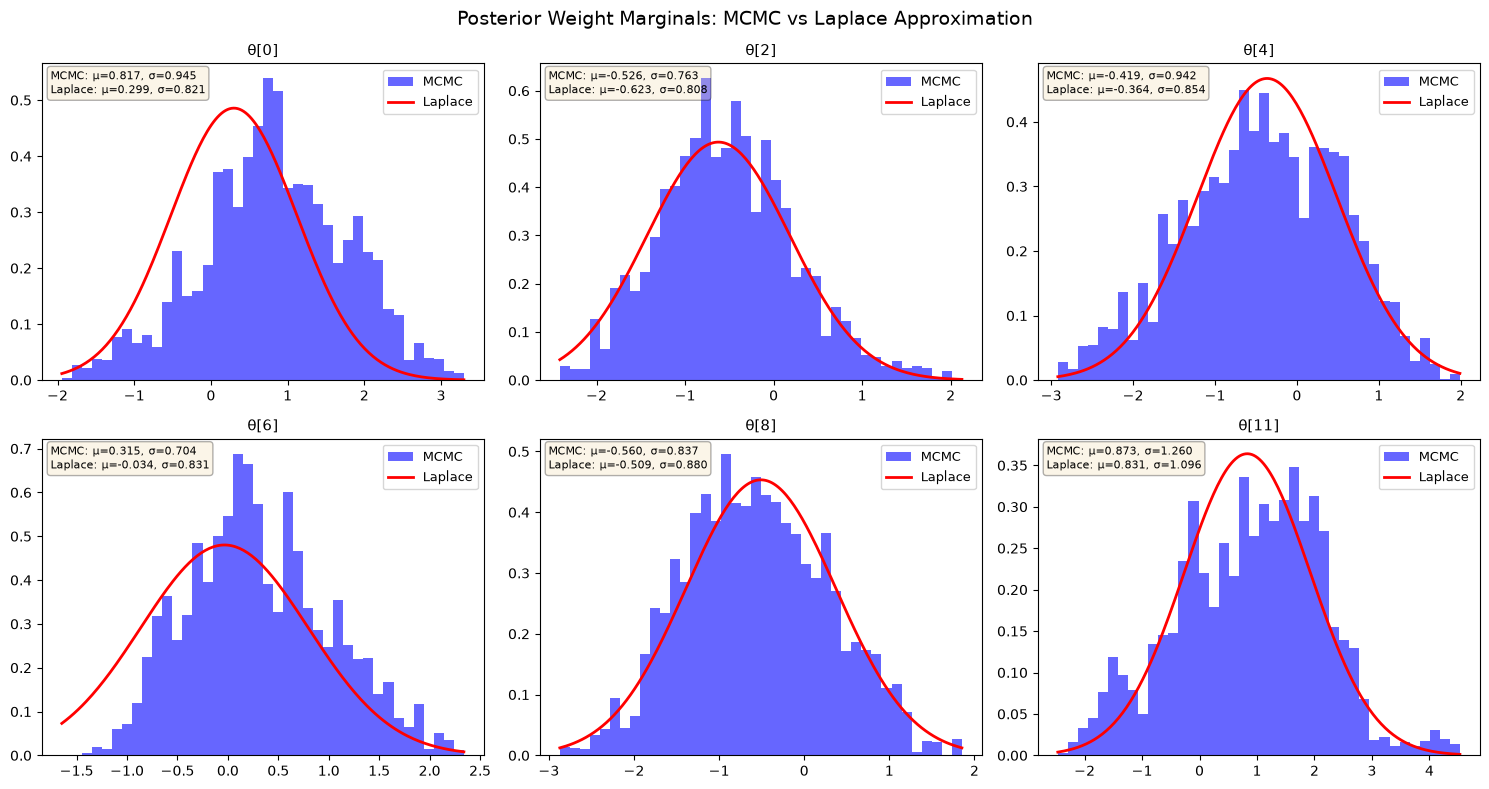

Visual check: Laplace (red) should closely match MCMC histogram (blue)


In [26]:
# Compare marginals for a few selected weight components
n_components_to_plot = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Select components spread across the parameter space
param_indices = np.linspace(0, laplace.theta_map.shape[0] - 1, n_components_to_plot, dtype=int)

for i, idx in enumerate(param_indices):
    ax = axes[i]
    
    # MCMC samples for this component
    mcmc_component = mcmc_samples[:, idx].numpy()
    
    # Laplace (Gaussian) for this component
    mean_laplace = laplace.theta_map[idx].item()
    std_laplace = torch.sqrt(laplace.cov[idx, idx]).item()
    
    # Plot MCMC histogram
    ax.hist(mcmc_component, bins=40, density=True, alpha=0.6, color='blue', label='MCMC')
    
    # Plot Laplace Gaussian
    x_range = np.linspace(mcmc_component.min(), mcmc_component.max(), 200)
    from scipy.stats import norm
    laplace_pdf = norm.pdf(x_range, mean_laplace, std_laplace)
    ax.plot(x_range, laplace_pdf, 'r-', linewidth=2, label='Laplace')
    
    # Statistics
    mcmc_mean = mcmc_component.mean()
    mcmc_std = mcmc_component.std()
    
    ax.set_title(f'θ[{idx}]', fontsize=11)
    ax.legend(fontsize=9)
    ax.text(0.02, 0.98, f'MCMC: μ={mcmc_mean:.3f}, σ={mcmc_std:.3f}\n'
                        f'Laplace: μ={mean_laplace:.3f}, σ={std_laplace:.3f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('Posterior Weight Marginals: MCMC vs Laplace Approximation', fontsize=14)
plt.tight_layout()
plt.show()

print("Visual check: Laplace (red) should closely match MCMC histogram (blue)")

## Compare Predictive Distributions on Test Set

In [27]:
# Compute predictive distributions
print("Computing predictive distributions...\n")

# 1. Laplace predictive
laplace_pred = laplace.predictive(model, X_test, M=1000, temperature=1.0, 
                                   generator=torch.Generator().manual_seed(42))

# 2. MCMC predictive (using posterior samples)
with torch.no_grad():
    phi_test = model.features(X_test)
    ones_test = torch.ones(N_test, 1)
    phi_aug_test = torch.cat([phi_test, ones_test], dim=1)  # (N_test, Dp)
    
    # Use subset of MCMC samples for computational efficiency
    n_mcmc_pred = 1000
    mcmc_indices = torch.randperm(mcmc_samples.shape[0])[:n_mcmc_pred]
    mcmc_subset = mcmc_samples[mcmc_indices].reshape(n_mcmc_pred, K, laplace.Dp)
    
    # Compute predictions for each MCMC sample
    logits_mcmc = torch.einsum('mkd,nd->mnk', mcmc_subset, phi_aug_test)  # (M, N_test, K)
    probs_mcmc = F.softmax(logits_mcmc, dim=-1)
    
    # MCMC predictive statistics
    mean_probs_mcmc = probs_mcmc.mean(dim=0)  # (N_test, K)
    total_ent_mcmc = entropy(mean_probs_mcmc)  # (N_test,)
    aleatoric_mcmc = entropy(probs_mcmc).mean(dim=0)  # (N_test,)
    epistemic_mcmc = (total_ent_mcmc - aleatoric_mcmc).clamp(min=0.0)

print("Predictive distributions computed.")

Computing predictive distributions...

Predictive distributions computed.


## Quantitative Comparison

In [28]:
# Compare mean predictions
mean_diff = (laplace_pred['mean_probs'] - mean_probs_mcmc).abs()
max_mean_diff = mean_diff.max().item()
avg_mean_diff = mean_diff.mean().item()

# Compare uncertainties
total_ent_diff = (laplace_pred['total_entropy'] - total_ent_mcmc).abs()
epistemic_diff = (laplace_pred['epistemic'] - epistemic_mcmc).abs()
aleatoric_diff = (laplace_pred['aleatoric'] - aleatoric_mcmc).abs()

print("="*60)
print("QUANTITATIVE COMPARISON")
print("="*60)
print("\nMean Predictions (class probabilities):")
print(f"  Max absolute difference:     {max_mean_diff:.4f}")
print(f"  Average absolute difference: {avg_mean_diff:.4f}")

print("\nUncertainty Estimates:")
print(f"  Total entropy - max diff:    {total_ent_diff.max().item():.4f}")
print(f"  Total entropy - avg diff:    {total_ent_diff.mean().item():.4f}")
print(f"  Epistemic - max diff:        {epistemic_diff.max().item():.4f}")
print(f"  Epistemic - avg diff:        {epistemic_diff.mean().item():.4f}")
print(f"  Aleatoric - max diff:        {aleatoric_diff.max().item():.4f}")
print(f"  Aleatoric - avg diff:        {aleatoric_diff.mean().item():.4f}")

# Correlation
from scipy.stats import pearsonr, spearmanr
corr_total, _ = pearsonr(laplace_pred['total_entropy'].numpy(), total_ent_mcmc.numpy())
corr_epi, _ = pearsonr(laplace_pred['epistemic'].numpy(), epistemic_mcmc.numpy())
corr_ale, _ = pearsonr(laplace_pred['aleatoric'].numpy(), aleatoric_mcmc.numpy())

print("\nCorrelations (Pearson):")
print(f"  Total entropy:   {corr_total:.4f}")
print(f"  Epistemic:       {corr_epi:.4f}")
print(f"  Aleatoric:       {corr_ale:.4f}")

QUANTITATIVE COMPARISON

Mean Predictions (class probabilities):
  Max absolute difference:     0.1645
  Average absolute difference: 0.0754

Uncertainty Estimates:
  Total entropy - max diff:    0.4233
  Total entropy - avg diff:    0.3239
  Epistemic - max diff:        0.0871
  Epistemic - avg diff:        0.0316
  Aleatoric - max diff:        0.3690
  Aleatoric - avg diff:        0.2923

Correlations (Pearson):
  Total entropy:   0.9393
  Epistemic:       0.7165
  Aleatoric:       0.9519


## Visual Comparison of Uncertainty Estimates

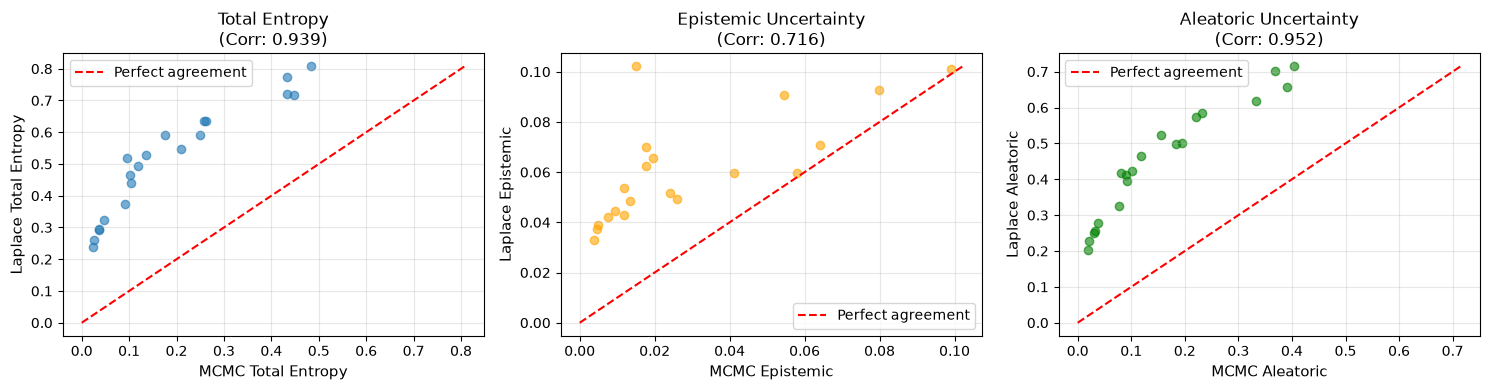

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total entropy
axes[0].scatter(total_ent_mcmc.numpy(), laplace_pred['total_entropy'].numpy(), alpha=0.6)
lim = max(total_ent_mcmc.max().item(), laplace_pred['total_entropy'].max().item())
axes[0].plot([0, lim], [0, lim], 'r--', label='Perfect agreement')
axes[0].set_xlabel('MCMC Total Entropy', fontsize=11)
axes[0].set_ylabel('Laplace Total Entropy', fontsize=11)
axes[0].set_title(f'Total Entropy\n(Corr: {corr_total:.3f})', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Epistemic
axes[1].scatter(epistemic_mcmc.numpy(), laplace_pred['epistemic'].numpy(), alpha=0.6, color='orange')
lim = max(epistemic_mcmc.max().item(), laplace_pred['epistemic'].max().item())
axes[1].plot([0, lim], [0, lim], 'r--', label='Perfect agreement')
axes[1].set_xlabel('MCMC Epistemic', fontsize=11)
axes[1].set_ylabel('Laplace Epistemic', fontsize=11)
axes[1].set_title(f'Epistemic Uncertainty\n(Corr: {corr_epi:.3f})', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Aleatoric
axes[2].scatter(aleatoric_mcmc.numpy(), laplace_pred['aleatoric'].numpy(), alpha=0.6, color='green')
lim = max(aleatoric_mcmc.max().item(), laplace_pred['aleatoric'].max().item())
axes[2].plot([0, lim], [0, lim], 'r--', label='Perfect agreement')
axes[2].set_xlabel('MCMC Aleatoric', fontsize=11)
axes[2].set_ylabel('Laplace Aleatoric', fontsize=11)
axes[2].set_title(f'Aleatoric Uncertainty\n(Corr: {corr_ale:.3f})', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()